Shapes: (10585, 120) (2647, 120)

=== CLASS BALANCE ===
Fresh vs Rotten: Counter({1: 5724, 0: 4861})
Fruit distribution: Counter({'Banana': 3726, 'Apple': 3627, 'Capsicum': 1380, 'Potato': 1151, 'Cucumber': 701})


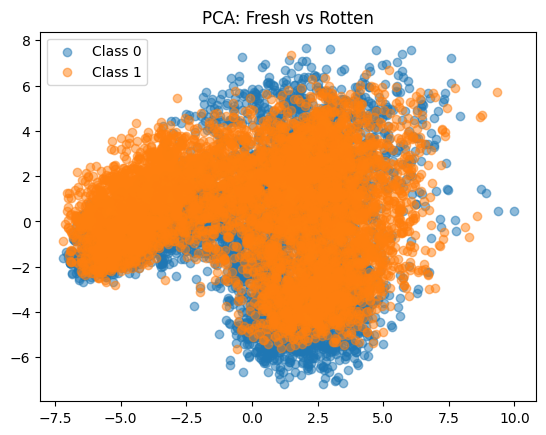

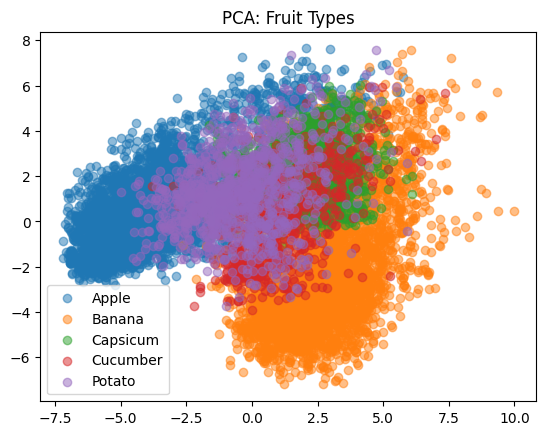

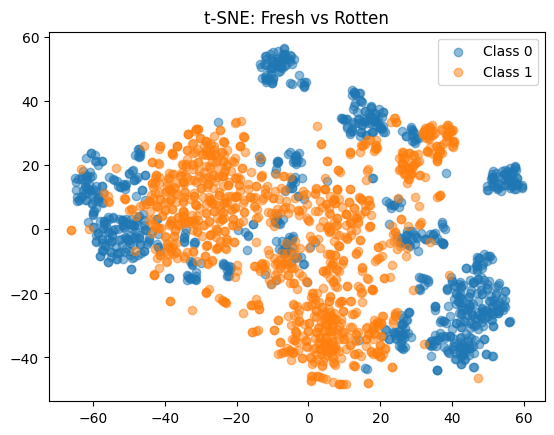

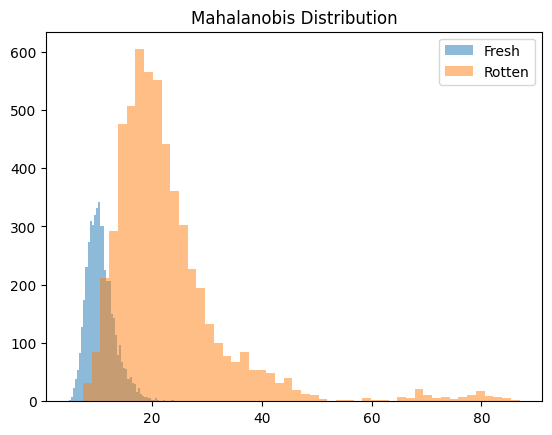

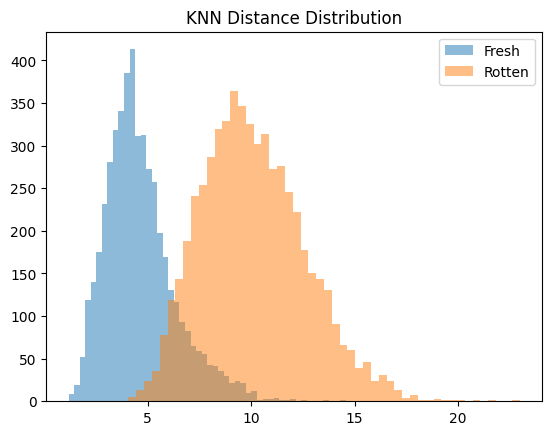

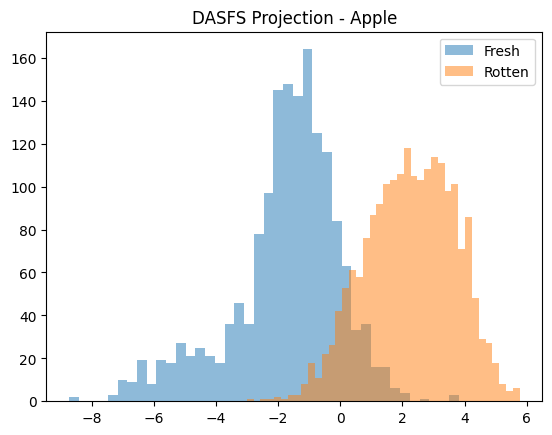

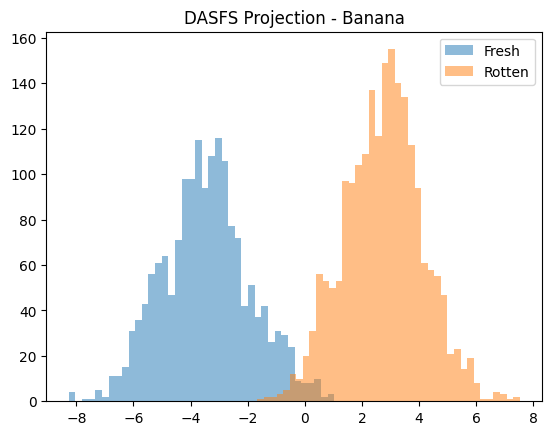

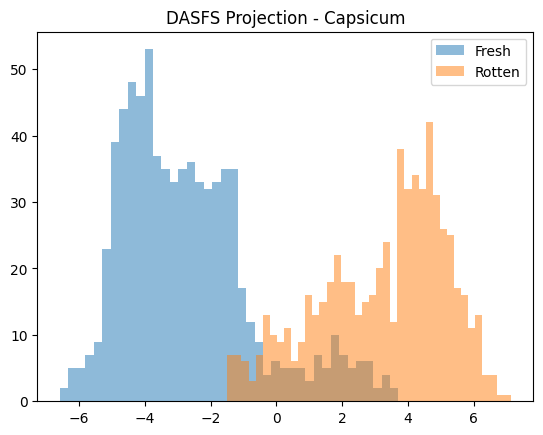

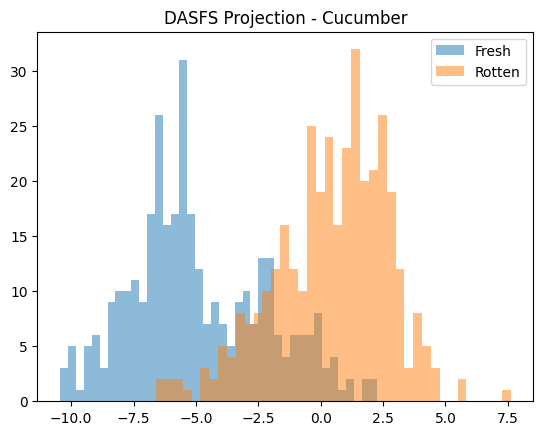

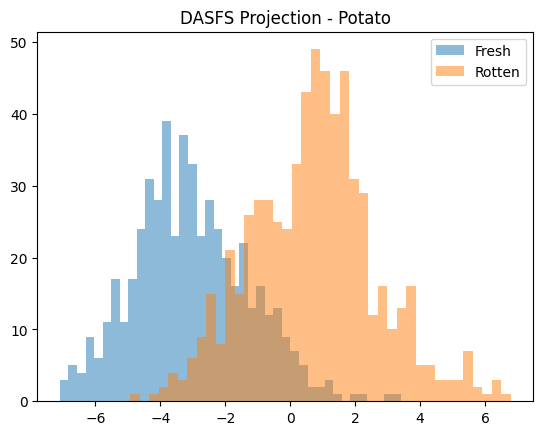

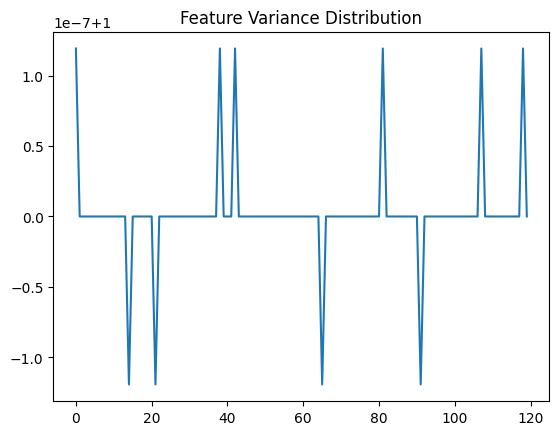


Top 20 high-variance features index:
[ 52  55  40  39  56  57  37  36  35  34  33  32  41  53 118  42  38  81
 107   0]


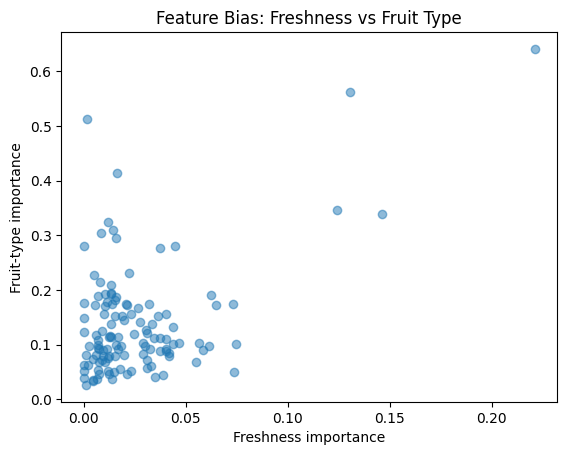


Mean MI (freshness): 0.02589367891689012
Mean MI (fruit): 0.13883757369965347

=== DIAGNOSTIC COMPLETE ===


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from collections import Counter
import joblib
import numpy.linalg as npl

# =========================
# LOAD DATA
# =========================
X_train = np.load("artifacts/X_train.npy")
X_test  = np.load("artifacts/X_test.npy")
y_train = np.load("artifacts/y_train.npy")
y_test  = np.load("artifacts/y_test.npy")
ft_train = np.load("artifacts/ft_train.npy", allow_pickle=True)
ft_test  = np.load("artifacts/ft_test.npy", allow_pickle=True)

mu = joblib.load("models/mu.pkl")
cov = joblib.load("models/cov.pkl")
knn = joblib.load("models/knn.pkl")
rfe = joblib.load("models/rfe.pkl")

print("Shapes:", X_train.shape, X_test.shape)

# =========================
# 1. CLASS BALANCE
# =========================
print("\n=== CLASS BALANCE ===")
print("Fresh vs Rotten:", Counter(y_train))
print("Fruit distribution:", Counter(ft_train))

# =========================
# 2. PCA CLUSTER PLOT
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure()
for label in np.unique(y_train):
    idx = y_train == label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=f"Class {label}", alpha=0.5)
plt.title("PCA: Fresh vs Rotten")
plt.legend()
plt.show()

plt.figure()
for fruit in np.unique(ft_train):
    idx = ft_train == fruit
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=fruit, alpha=0.5)
plt.title("PCA: Fruit Types")
plt.legend()
plt.show()

# =========================
# 3. t-SNE (better separation check)
# =========================
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train[:2000])  # limit for speed
y_sub = y_train[:2000]
ft_sub = ft_train[:2000]

plt.figure()
for label in np.unique(y_sub):
    idx = y_sub == label
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], label=f"Class {label}", alpha=0.5)
plt.title("t-SNE: Fresh vs Rotten")
plt.legend()
plt.show()

# =========================
# 4. MAHALANOBIS DISTANCE
# =========================
def mahal(X, ft):
    M = np.zeros(len(X))
    for f in np.unique(ft):
        idx = (ft == f)
        if f not in mu:
            continue
        inv = npl.pinv(cov[f])
        diff = X[idx] - mu[f]
        M[idx] = np.sqrt(np.sum(diff @ inv * diff, axis=1))
    return M

M_train = mahal(X_train, ft_train)

plt.figure()
plt.hist(M_train[y_train==0], bins=50, alpha=0.5, label="Fresh")
plt.hist(M_train[y_train==1], bins=50, alpha=0.5, label="Rotten")
plt.legend()
plt.title("Mahalanobis Distribution")
plt.show()

# =========================
# 5. KNN DISTANCE
# =========================
K_train = knn.kneighbors(X_train)[0].mean(axis=1)

plt.figure()
plt.hist(K_train[y_train==0], bins=50, alpha=0.5, label="Fresh")
plt.hist(K_train[y_train==1], bins=50, alpha=0.5, label="Rotten")
plt.legend()
plt.title("KNN Distance Distribution")
plt.show()

# =========================
# 6. DASFS PROJECTION
# =========================
dasfs_dict = {}

for f in np.unique(ft_train):
    idx_fresh  = (ft_train == f) & (y_train == 0)
    idx_rotten = (ft_train == f) & (y_train == 1)

    if idx_fresh.sum() < 5 or idx_rotten.sum() < 5:
        continue

    mu_f = X_train[idx_fresh].mean(axis=0)
    mu_r = X_train[idx_rotten].mean(axis=0)

    axis = mu_r - mu_f
    axis = axis / (np.linalg.norm(axis) + 1e-8)

    proj = X_train[ft_train == f] @ axis
    labels = y_train[ft_train == f]

    plt.figure()
    plt.hist(proj[labels==0], bins=40, alpha=0.5, label="Fresh")
    plt.hist(proj[labels==1], bins=40, alpha=0.5, label="Rotten")
    plt.title(f"DASFS Projection - {f}")
    plt.legend()
    plt.show()

# =========================
# 7. FEATURE IMPORTANCE CHECK
# =========================
# Check which features dominate
variances = X_train.var(axis=0)

plt.figure()
plt.plot(variances)
plt.title("Feature Variance Distribution")
plt.show()

print("\nTop 20 high-variance features index:")
print(np.argsort(variances)[-20:])

# =========================
# 8. FRESH vs FRUIT SIGNAL STRENGTH
# =========================
from sklearn.feature_selection import mutual_info_classif

mi_fresh = mutual_info_classif(X_train, y_train)
mi_fruit = mutual_info_classif(X_train, ft_train)

plt.figure()
plt.scatter(mi_fresh, mi_fruit, alpha=0.5)
plt.xlabel("Freshness importance")
plt.ylabel("Fruit-type importance")
plt.title("Feature Bias: Freshness vs Fruit Type")
plt.show()

print("\nMean MI (freshness):", mi_fresh.mean())
print("Mean MI (fruit):", mi_fruit.mean())

# =========================
# FINAL SUMMARY PRINT
# =========================
print("\n=== DIAGNOSTIC COMPLETE ===")

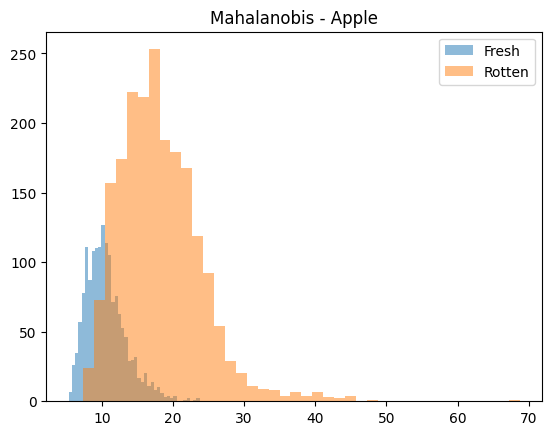

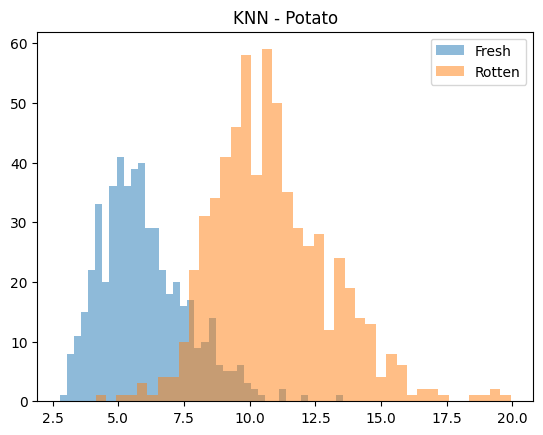

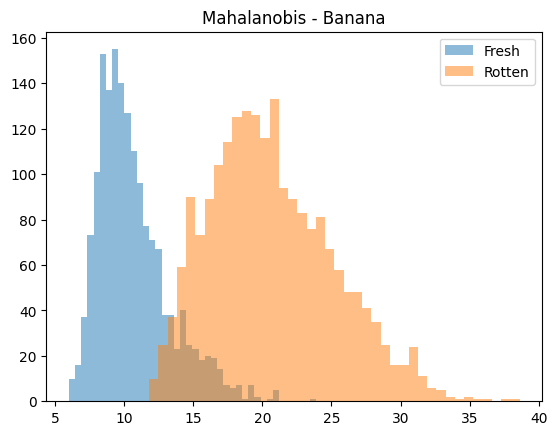

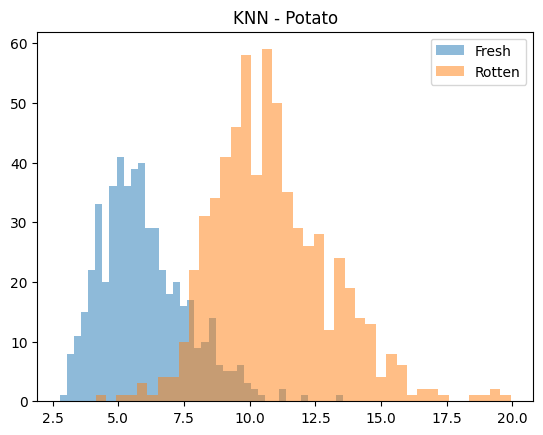

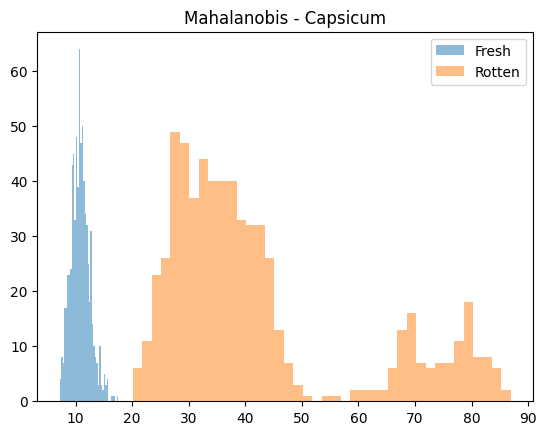

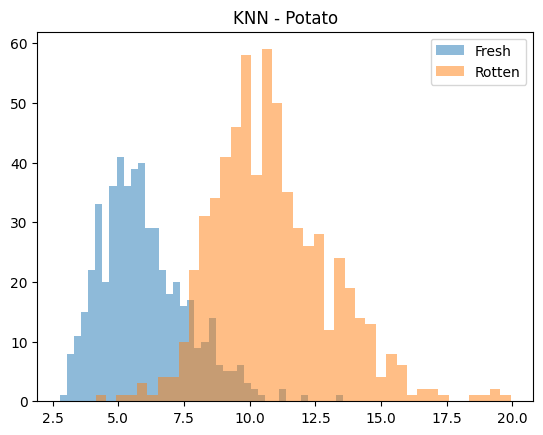

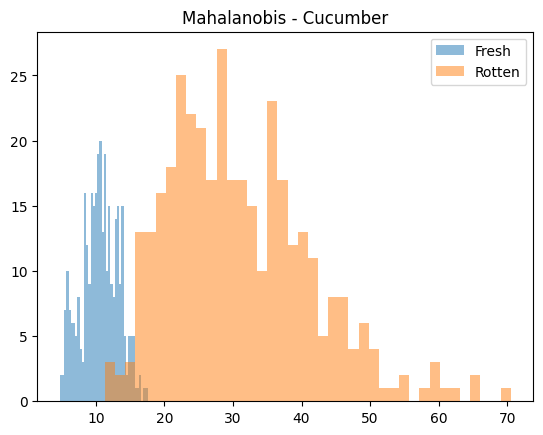

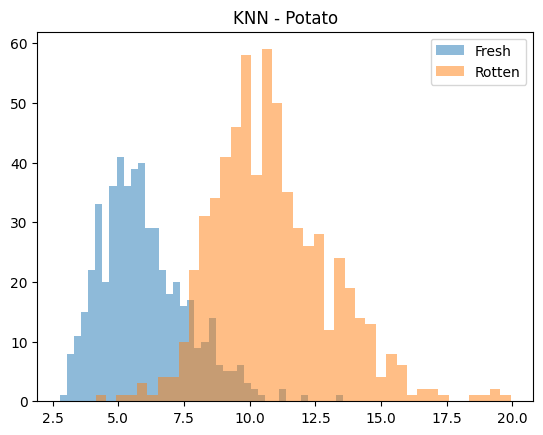

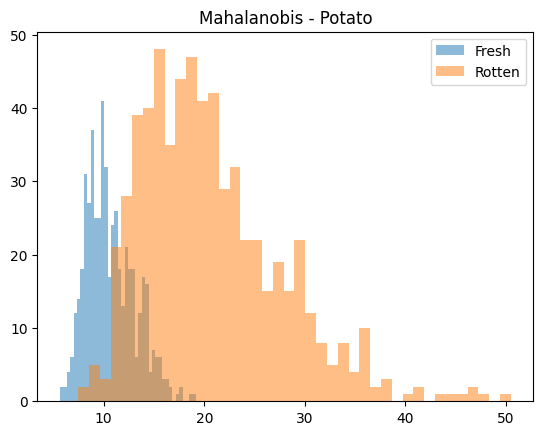

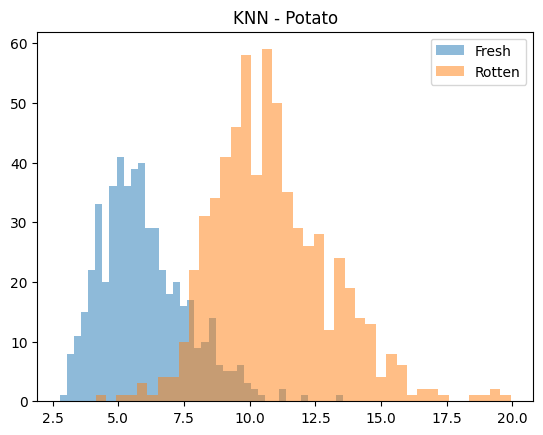

In [5]:
for f in np.unique(ft_train):
    idx = ft_train == f

    M_f = M_train[idx]
    y_f = y_train[idx]

    plt.figure()
    plt.hist(M_f[y_f==0], bins=40, alpha=0.5, label="Fresh")
    plt.hist(M_f[y_f==1], bins=40, alpha=0.5, label="Rotten")
    plt.title(f"Mahalanobis - {f}")
    plt.legend()
    plt.show()
    for f in np.unique(ft_train):
        idx = ft_train == f

    K_f = K_train[idx]
    y_f = y_train[idx]

    plt.figure()
    plt.hist(K_f[y_f==0], bins=40, alpha=0.5, label="Fresh")
    plt.hist(K_f[y_f==1], bins=40, alpha=0.5, label="Rotten")
    plt.title(f"KNN - {f}")
    plt.legend()
    plt.show()